# 공공 자전거 장기 연체 예측
- 목표 : 대여 시점 정보로 100분 초과 장기 연체(`is_overdue_100m`) 예측
- 핵심 질문 : "정확도 84%인데 왜 연체를 하나도 못 잡았나?"

## [STEP 1] 파생변수 & 정답지(Target)
- `duration_min` = `return_time - rent_time` (분 단위)
- `is_overdue_100m` = `duration_min > 100` 이면 1 (예측 대상)
- `hour`, `weekday` = `rent_time` 기준 시간대, 요일 → 연체 비율, "전부 정상" 예측 시 정확도 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"    # 윈도우 기본 한글 폰트 (맑은 고딕)
plt.rcParams["axes.unicode_minus"] = False       # 마이너스(-) 기호 깨짐 방지

df = pd.read_csv("data/clean_rentals.csv", parse_dates=["rent_time", "return_time"])

print(f"전체 행, 열 수 : {df.shape}")
print("[컬럼별 자료형]")
display(df.dtypes.to_frame("자료형"))

전체 행, 열 수 : (13501, 16)
[컬럼별 자료형]


,자료형
rental_id,str
bike_id,str
user_id,str
rent_time,datetime64[us]
return_time,datetime64[us]
distance_km,float64
fee,int64
payment_method,str
station_id,str
bike_type,str


In [2]:
# 1. 대여시간(분)
diff = df["return_time"] - df["rent_time"]
df["duration_min"] = diff.dt.total_seconds() / 60

print("[대여 시간(분) 계산 결과 - 상위 5행]")
display(df[["rent_time", "return_time", "duration_min"]].head())

[대여 시간(분) 계산 결과 - 상위 5행]


,rent_time,return_time,duration_min
0,2022-04-18 20:28:00,2022-04-18 20:44:00,16.0
1,2022-05-19 09:53:00,2022-05-19 11:08:00,75.0
2,2022-09-07 16:20:00,2022-09-07 18:04:00,104.0
3,2022-10-11 06:39:00,2022-10-11 07:18:00,39.0
4,2022-07-11 10:15:00,2022-07-11 10:53:00,38.0


In [3]:
# 2. 정답지 : 100분 초과면 1
df["is_overdue_100m"] = (df["duration_min"] > 100).astype(int)

print("[연체 여부별 건수] 0 = 정상, 1 = 연체")
display(df["is_overdue_100m"].value_counts().to_frame("건수"))

[연체 여부별 건수] 0 = 정상, 1 = 연체


,건수
is_overdue_100m,
0,11136
1,2365


In [4]:
# 3. 대여 시점 기준 시간대, 요일
df["hour"] = df["rent_time"].dt.hour
df["weekday"] = df["rent_time"].dt.weekday

print("[시간대, 요일 추출 결과 - 상위 5행]")
display(df[["rent_time", "hour", "weekday"]].head())

[시간대, 요일 추출 결과 - 상위 5행]


,rent_time,hour,weekday
0,2022-04-18 20:28:00,20,0
1,2022-05-19 09:53:00,9,3
2,2022-09-07 16:20:00,16,2
3,2022-10-11 06:39:00,6,1
4,2022-07-11 10:15:00,10,0


In [5]:
# 4. 연체 비율, "전부 정상" 예측 시 정확도
overdue_ratio = df["is_overdue_100m"].mean()
all_normal_acc = 1 - overdue_ratio

print(f"전체 행 수 : {len(df):,}")
print(f"연체 비율 : {overdue_ratio:.2%}")
print(f"'전부 정상' 예측 시 정확도 : {all_normal_acc:.2%}")

전체 행 수 : 13,501
연체 비율 : 17.52%
'전부 정상' 예측 시 정확도 : 82.48%


## [STEP 2] users 결합 & 가입 기간(파생변수)
- `users.csv` 를 `user_id` 기준으로 결합 (`how`, `validate` 명시) → 결합 전후 행 수 비교
- 가입 기간(일) = `rent_time - join_date`

In [6]:
# 5. users 불러오기
users = pd.read_csv("data/users.csv", parse_dates=["join_date"])

# 6. 결합
before = len(df)

df = df.merge(
    users,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print(f"결합 전: {before:,}행")
print(f"결합 후: {len(df):,}행")

결합 전: 13,501행
결합 후: 13,501행


In [7]:
# 7. 가입 기간(일) = 대여시점 - 가입일
df["member_days"] = (df["rent_time"] - df["join_date"]).dt.days

print("[가입 기간(일) 요약]")
display(df["member_days"].describe().round(1).to_frame("가입 기간(일)"))

[가입 기간(일) 요약]


,가입 기간(일)
count,13501.0
mean,49.9
std,312.7
min,-622.0
25%,-207.0
50%,42.0
75%,312.0
max,720.0


In [8]:
# 확인용 : 가입 기간 음수 원인
neg = df["member_days"] < 0

print(f"가입 기간 음수 : {neg.sum():,}건 ({neg.mean():.2%})")
print(f"대여일 범위 : {df['rent_time'].min()} ~ {df['rent_time'].max()}")
print(f"가입일 범위 : {users['join_date'].min()} ~ {users['join_date'].max()}")

가입 기간 음수 : 6,160건 (45.63%)
대여일 범위 : 2022-01-01 07:26:00 ~ 2022-12-31 22:52:00
가입일 범위 : 2021-01-01 00:00:00 ~ 2023-09-27 00:00:00


In [9]:
# 8. 가입 기간 음수 처리 : 기본은 0으로 대체 (나머지 방법은 마지막에 비교)
df["member_days_raw"] = df["member_days"]                # 원본 보관 (비교 실험용)
df["join_error"] = (df["member_days"] < 0).astype(int)   # 원래 음수였으면 1
df["member_days"] = df["member_days"].clip(lower=0)      # 음수 → 0

print(f"가입 전 대여(음수) : {df['join_error'].sum():,}건 ({df['join_error'].mean():.2%})")
print("[처리 후 가입 기간(일) 요약]")
display(df["member_days"].describe().round(1).to_frame("가입 기간(일)"))

가입 전 대여(음수) : 6,160건 (45.63%)
[처리 후 가입 기간(일) 요약]


,가입 기간(일)
count,13501.0
mean,159.5
std,196.7
min,0.0
25%,0.0
50%,42.0
75%,312.0
max,720.0


## [STEP 3] 데이터 누수 탐지
- 기준 : 대여 순간(`rent_time`)에 알 수 있는 값인가? → 반납 후에야 확정되는 값은 제외

In [10]:
print("[현재 컬럼 목록]")
print(df.columns.tolist())

[현재 컬럼 목록]
['rental_id', 'bike_id', 'user_id', 'rent_time', 'return_time', 'distance_km', 'fee', 'payment_method', 'station_id', 'bike_type', 'gear_count', 'manufacture_year', 'daily_fee', 'station_name', 'district', 'duration_min', 'is_overdue_100m', 'hour', 'weekday', 'join_date', 'membership_type', 'member_days', 'member_days_raw', 'join_error']


In [11]:
# 9. 누수 컬럼 (반납 후에야 확정되는 값)
LEAK_COLS = ["return_time", "duration_min", "distance_km", "fee"]

# 누수는 아니지만 학습에 쓰지 않는 컬럼 (ID, 날짜 원본, 비교용)
ID_DATE_COLS = ["rental_id", "bike_id", "user_id", "station_id", "station_name",
                "rent_time", "join_date", "member_days_raw"]

# 정답
TARGET = "is_overdue_100m"

print(f"누수 컬럼 : {LEAK_COLS}")
print(f"제외 컬럼 : {ID_DATE_COLS}")
print(f"정답 : {TARGET}")

# 10. 학습에 쓸 피처 = 전체 - 누수 - 제외 - 정답
DROP_COLS = LEAK_COLS + ID_DATE_COLS + [TARGET]

FEATURES = [c for c in df.columns if c not in DROP_COLS]

print(f"피처 개수 : {len(FEATURES)}")
print(f"피처 목록 : {FEATURES}")

누수 컬럼 : ['return_time', 'duration_min', 'distance_km', 'fee']
제외 컬럼 : ['rental_id', 'bike_id', 'user_id', 'station_id', 'station_name', 'rent_time', 'join_date', 'member_days_raw']
정답 : is_overdue_100m
피처 개수 : 11
피처 목록 : ['payment_method', 'bike_type', 'gear_count', 'manufacture_year', 'daily_fee', 'district', 'hour', 'weekday', 'membership_type', 'member_days', 'join_error']


## [STEP 4] 학습 / 테스트 분할 & 인코딩
- `rent_time` 기준 상위 80% 날짜로 분할 (랜덤 분할 X) → 범주형 인코딩 → 테스트 열을 학습 열에 맞춤

In [12]:
# 11. 시점 기준 분할 (80% : 20%)
cutoff = df["rent_time"].quantile(0.8)

train = df[df["rent_time"] <= cutoff]
test = df[df["rent_time"] > cutoff]

print("=" * 60)

print(f"기준선 : {cutoff}")
print(f"학습 : {len(train):,}행 ({train['rent_time'].min().date()} ~ {train['rent_time'].max().date()})")
print(f"테스트 : {len(test):,}행 ({test['rent_time'].min().date()} ~ {test['rent_time'].max().date()})")
print()
print("=" * 60)

# 12. X, y 분리
X_train = train[FEATURES]
X_test = test[FEATURES]
y_train = train[TARGET]
y_test = test[TARGET]

# 13. 범주형 원핫 인코딩
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

print(f"인코딩 후 학습 열 수 : {X_train.shape[1]}")
print(f"인코딩 후 테스트 열 수 : {X_test.shape[1]}")
print()
print("=" * 60)

# 14. 테스트 열을 학습 열에 맞추기 (없는 열은 0으로 채움)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"학습 열 수 : {X_train.shape[1]}, 테스트 열 수 : {X_test.shape[1]}")
print(f"열 순서까지 같음 : {list(X_train.columns) == list(X_test.columns)}")
print()
print("=" * 60)

# 15. 결측값 확인
na = X_train.isna().sum()

print("[학습 데이터 결측 값 - 1개 이상인 열만]")
display(na[na > 0].to_frame("결측 수"))
print()
print("=" * 60)

# 16. 결측 채우기 : 학습 데이터의 중앙값으로 (테스트도 같은 값)
med_year = X_train["manufacture_year"].median()

X_train["manufacture_year"] = X_train["manufacture_year"].fillna(med_year)
X_test["manufacture_year"] = X_test["manufacture_year"].fillna(med_year)

print(f"채운 값(학습 중앙값) : {med_year}")
print(f"남은 결측 - 학습 : {X_train.isna().sum().sum()}, 테스트 : {X_test.isna().sum().sum()}")

기준선 : 2022-10-20 16:21:00
학습 : 10,801행 (2022-01-01 ~ 2022-10-20)
테스트 : 2,700행 (2022-10-20 ~ 2022-12-31)

인코딩 후 학습 열 수 : 24
인코딩 후 테스트 열 수 : 24

학습 열 수 : 24, 테스트 열 수 : 24
열 순서까지 같음 : True

[학습 데이터 결측 값 - 1개 이상인 열만]


,결측 수
manufacture_year,1326



채운 값(학습 중앙값) : 2018.0
남은 결측 - 학습 : 0, 테스트 : 0


## [STEP 5] 누수의 위력 확인
- 누수 컬럼(`duration_min`)을 일부러 넣은 피처 vs 뺀 피처 → RandomForest로 성능 비교

In [13]:
# 17. 누수 포함 피처 만들기 (비교용)
X_train_leak = X_train.copy()
X_test_leak = X_test.copy()

X_train_leak["duration_min"] = train["duration_min"]
X_test_leak["duration_min"] = test["duration_min"]

print("="*60)
print(f"누수 제외 : {X_train.shape[1]}열")
print(f"누수 포함 : {X_train_leak.shape[1]}열")
print()
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42

# 18. 누수 제외 vs 포함 비교
data_sets = {
    "누수 제외": (X_train, X_test),
    "누수 포함": (X_train_leak, X_test_leak)
}

rows = []

for name, (Xtr, Xte) in data_sets.items():
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
    model.fit(Xtr, y_train)

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    
    rows.append({
        "피처": name,
        "정확도": accuracy_score(y_test, pred),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
    })

display(pd.DataFrame(rows).round(4))

누수 제외 : 24열
누수 포함 : 25열



,피처,정확도,재현율,F1,AUC
0,누수 제외,0.8193,0.0,0.0,0.4957
1,누수 포함,1.0000,1.0,1.0,1.0000


## [STEP 6] 모델 비교
- Dummy / LR / LR(balanced) / RF / RF(balanced) → 정확도, 정밀도, 재현율, F1, AUC 비교

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def with_scaler(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# 19. 비교할 모델 5개
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LR": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)),
    "LR(balanced)": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
    "RF": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "RF(balanced)": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1, class_weight="balanced"),
}

print(list(models.keys()))

['Dummy', 'LR', 'LR(balanced)', 'RF', 'RF(balanced)']


In [15]:
from sklearn.metrics import precision_score

# 20. 모델 5개 학습 & 평가
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_test, pred),
        "정밀도": precision_score(y_test, pred, zero_division=0),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
    })

result = pd.DataFrame(rows)
display(result.round(4))

,모델,정확도,정밀도,재현율,F1,AUC
0,Dummy,0.8193,0.0000,0.0000,0.0000,0.5000
1,LR,0.8193,0.0000,0.0000,0.0000,0.4828
2,LR(balanced),0.4907,0.1741,0.4857,0.2564,0.4824
3,RF,0.8193,0.0000,0.0000,0.0000,0.4957
4,RF(balanced),0.5622,0.1733,0.3770,0.2374,0.4865


## [STEP 7] 혼동행렬과 지표
- `RF(balanced)` 의 TP, FN, FP, TN → 자전거 관점에서 해석, FN vs FP 중 치명적인 쪽 판단

In [16]:
from sklearn.metrics import confusion_matrix

# 21. RF(balanced) 혼동행렬
rf_bal = models["RF(balanced)"]
pred = rf_bal.predict(X_test)

cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

print("[혼동행렬]")
display(pd.DataFrame(cm,
                     index=["실제 정상(0)", "실제 연체(1)"],
                     columns=["예측 정상(0)", "예측 연체(1)"]))
print(f"TP : {tp}, FN : {fn}, FP : {fp}, TN : {tn}")

[혼동행렬]


,예측 정상(0),예측 연체(1)
실제 정상(0),1334,878
실제 연체(1),304,184


TP : 184, FN : 304, FP : 878, TN : 1334


## [STEP 8] 비용 기반 임계값 선택
- 임계값 0.05 ~ 0.95 → TP, FN, FP, 재현율, 정밀도, 총비용(FN × 15,000 + FP × 2,000) → 총비용 최소 임계값 찾기

In [17]:
COST_FN = 15000   # 연체를 놓침
COST_FP = 2000    # 정상을 의심

# 22. 임계값별 비용 계산
proba = rf_bal.predict_proba(X_test)[:, 1]   # 연체일 확률

rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred_t = (proba >= t).astype(int)        # 확률이 t 이상이면 연체로 예측
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    rows.append({
        "임계값": round(t, 2),
        "TP": tp, "FN": fn, "FP": fp,
        "재현율": recall_score(y_test, pred_t, zero_division=0),
        "정밀도": precision_score(y_test, pred_t, zero_division=0),
        "총비용": fn * COST_FN + fp * COST_FP,
    })

cost_df = pd.DataFrame(rows)
display(cost_df.round(3))
print()
print("="*60)

# 23. 총비용 최소 임계값
best_idx = cost_df["총비용"].idxmin()
best = cost_df.loc[best_idx]

print("[총비용 최소 지점]")
print(f"임계값 : {best['임계값']:.2f}")
print(f"TP : {best['TP']:.0f}, FN : {best['FN']:.0f}, FP : {best['FP']:.0f}")
print(f"재현율 : {best['재현율']:.3f}, 정밀도 : {best['정밀도']:.3f}")
print(f"총비용 : {best['총비용']:,.0f}원")
print()
print("="*60)

# 24. "아무 예측 안 함" 비용과 비교
base_fn = y_test.sum()                 # 전부 정상 예측 → 실제 연체 전부가 FN
base_cost = base_fn * COST_FN          # FP는 0건

saving = base_cost - best["총비용"]

print(f"아무 예측 안 함 : FN {base_fn}건 → {base_cost:,.0f}원")
print(f"최적 임계값({best['임계값']:.2f}) : {best['총비용']:,.0f}원")
print(f"절감액 : {saving:,.0f}원 ({saving / base_cost:.1%} 절감)")

,임계값,TP,FN,FP,재현율,정밀도,총비용
0,0.05,488,0,2212,1.000,0.181,4424000
1,0.10,488,0,2212,1.000,0.181,4424000
2,0.15,488,0,2212,1.000,0.181,4424000
3,0.20,488,0,2212,1.000,0.181,4424000
4,0.25,488,0,2212,1.000,0.181,4424000
5,0.30,488,0,2212,1.000,0.181,4424000
6,0.35,488,0,2211,1.000,0.181,4422000
7,0.40,484,4,2195,0.992,0.181,4450000
8,0.45,440,48,2015,0.902,0.179,4750000
9,0.50,184,304,878,0.377,0.173,6316000



[총비용 최소 지점]
임계값 : 0.35
TP : 488, FN : 0, FP : 2211
재현율 : 1.000, 정밀도 : 0.181
총비용 : 4,422,000원

아무 예측 안 함 : FN 488건 → 7,320,000원
최적 임계값(0.35) : 4,422,000원
절감액 : 2,898,000원 (39.6% 절감)


## [STEP 9] 피처 중요도와 해석
- 최종 모델(`RF(balanced)`) 피처 중요도 상위 5개 막대그래프 → 운영팀 모니터링 포인트 3줄 정리

[피처 중요도 상위 5개]


,중요도
member_days,0.2031
hour,0.1717
weekday,0.1146
manufacture_year,0.0900
join_error,0.0496


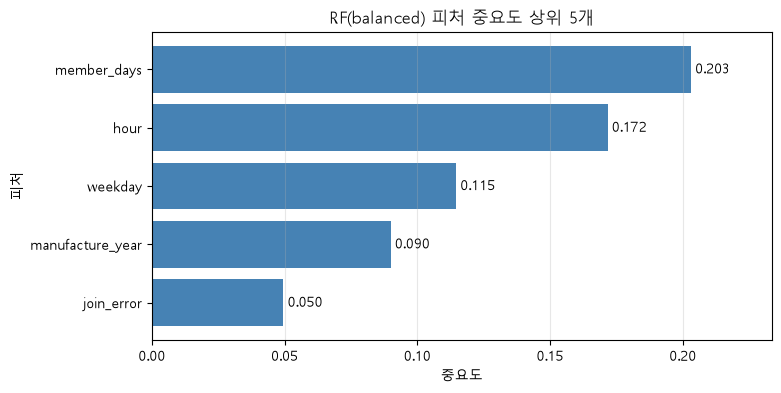

In [18]:
# 25. 피처 중요도 상위 5개
imp = pd.Series(rf_bal.feature_importances_, index=X_train.columns)
top5 = imp.sort_values(ascending=False).head(5)

print("[피처 중요도 상위 5개]")
display(top5.round(4).to_frame("중요도"))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5.index[::-1], top5.values[::-1], color="steelblue")

ax.bar_label(bars, fmt="%.3f", padding=3)   # 막대 끝에 값 표시
ax.set_xlabel("중요도")
ax.set_ylabel("피처")                        # y축 이름 추가
ax.set_title("RF(balanced) 피처 중요도 상위 5개")
ax.set_xlim(0, top5.max() * 1.15)           # 숫자가 잘리지 않게 오른쪽 여유
ax.grid(alpha=0.3, axis="x")
plt.show()

#### 운영팀 보고
1. 모델이 가장 많이 참고한 정보는 **가입 기간 > 대여 시간대 > 요일** 순이므로, 대여 시점에 이 세 가지를 우선 기록·모니터링할 필요가 있다.
2. 단, 현재 모델의 AUC가 약 0.49로 연체를 구분하지 못해, 이 정보만으로 연체 고객을 골라낼 수는 없다.
3. 연체를 놓치는 비용(15,000원)이 독촉 비용(2,000원)보다 커서 당분간은 전원 독촉이 유리하며, 과거 연체 이력 등 새로운 정보를 추가로 수집해야 한다.

## [추가 실험 1] 가입 기간 음수 처리 4가지 비교
- ① 삭제 / ② 0으로 대체 / ③ -1로 표시 / ④ 중앙값 대체 → 같은 모델(RF balanced), 같은 지표로 비교

In [19]:
# 26. 처리 방법별로 데이터를 만들고 RF(balanced) 학습 → 지표 반환
def run(method):
    d = df.copy()
    raw = d["member_days_raw"]

    if method == "① 삭제":
        d = d[raw >= 0].copy()                    # 음수가 아닌 행만 남김
        d["member_days"] = d["member_days_raw"]
    elif method == "② 0으로 대체":
        d["member_days"] = raw.clip(lower=0)
    elif method == "③ -1로 표시":
        d["member_days"] = raw.where(raw >= 0, -1)   # 음수 → -1
    elif method == "④ 중앙값 대체":
        d["member_days"] = raw.where(raw >= 0)       # 음수 → NaN (분할 후 채움)

    # 분할 (STEP 4와 같은 기준선)
    tr = d[d["rent_time"] <= cutoff]
    te = d[d["rent_time"] > cutoff]

    # 인코딩 + 열 맞추기
    Xtr = pd.get_dummies(tr[FEATURES])
    Xte = pd.get_dummies(te[FEATURES]).reindex(columns=Xtr.columns, fill_value=0)

    # 결측 채우기 : 학습 데이터 중앙값으로 (④의 member_days 포함)
    for col in ["manufacture_year", "member_days"]:
        med = Xtr[col].median()
        Xtr[col] = Xtr[col].fillna(med)
        Xte[col] = Xte[col].fillna(med)

    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED,
                                   n_jobs=-1, class_weight="balanced")
    model.fit(Xtr, tr[TARGET])

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    y = te[TARGET]

    return {
        "방법": method,
        "학습 행": len(Xtr),
        "테스트 행": len(Xte),
        "정확도": accuracy_score(y, pred),
        "재현율": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "AUC": roc_auc_score(y, proba),
    }

methods = ["① 삭제", "② 0으로 대체", "③ -1로 표시", "④ 중앙값 대체"]
compare = pd.DataFrame([run(m) for m in methods])

print("[가입 기간 음수 처리 방법별 비교 - RF(balanced)]")
display(compare.round(4))

[가입 기간 음수 처리 방법별 비교 - RF(balanced)]


,방법,학습 행,테스트 행,정확도,재현율,F1,AUC
0,① 삭제,5468,1873,0.6161,0.3254,0.2327,0.5005
1,② 0으로 대체,10801,2700,0.5622,0.3770,0.2374,0.4865
2,③ -1로 표시,10801,2700,0.5619,0.3791,0.2382,0.4916
3,④ 중앙값 대체,10801,2700,0.5826,0.3484,0.2318,0.4844


#### 결과
- 네 방법 모두 AUC 0.48 ~ 0.50 으로 차이가 거의 없고, 모두 동전 던지기 수준
- ① 삭제는 데이터 약 45% 손실 + 테스트 데이터가 달라져 공정한 비교가 아님
- 결론 : 행을 잃지 않는 단순한 방법(② 0 대체 / ③ -1 표시)이면 충분. 성능이 낮은 원인은 음수 처리가 아님

## [추가 실험 2] 피처별 단독 예측력 확인
- 피처 하나씩 AUC 계산 (0.5 = 구분 못 함) → 데이터 자체에 연체를 예측할 정보가 있는지 확인

In [20]:
# 27. 숫자형 피처별 단독 AUC
num_cols = ["member_days", "hour", "weekday", "manufacture_year", "daily_fee", "gear_count"]

auc_rows = []
for col in num_cols:
    x = df[col].fillna(df[col].median())        # 결측은 중앙값으로
    auc = roc_auc_score(df["is_overdue_100m"], x)      # 정답, 피처값
    auc_rows.append({"피처": col, "단독 AUC": auc})

print("[피처별 단독 AUC - 0.5에 가까울수록 예측력 없음]")
display(pd.DataFrame(auc_rows).round(3))

[피처별 단독 AUC - 0.5에 가까울수록 예측력 없음]


,피처,단독 AUC
0,member_days,0.510
1,hour,0.496
2,weekday,0.501
3,manufacture_year,0.507
4,daily_fee,0.503
5,gear_count,0.503


In [21]:
# 28. 범주형 피처별 그룹 연체 비율
cat_cols = ["bike_type", "payment_method", "membership_type", "district"]

for col in cat_cols:
    rate = df.groupby(col)["is_overdue_100m"].mean()
    print(f"[{col}] 그룹별 연체 비율 (차이 : {rate.max() - rate.min():.1%}p)")
    display(rate.map("{:.1%}".format).to_frame("연체 비율"))
    print()

[bike_type] 그룹별 연체 비율 (차이 : 0.6%p)


,연체 비율
bike_type,
일반,17.4%
전동,18.0%



[payment_method] 그룹별 연체 비율 (차이 : 0.8%p)


,연체 비율
payment_method,
APP,17.9%
CARD,17.5%
MEMBERSHIP,17.1%



[membership_type] 그룹별 연체 비율 (차이 : 1.7%p)


,연체 비율
membership_type,
BASIC,17.0%
PREMIUM,18.7%



[district] 그룹별 연체 비율 (차이 : 5.5%p)


,연체 비율
district,
강남구,15.1%
강동구,18.3%
강북구,17.1%
강서구,17.7%
관악구,19.5%
광진구,17.3%
구로구,15.3%
금천구,16.6%
노원구,14.0%


#### 결과
- 숫자형 단독 AUC 가 모두 0.50 ± 0.01 → 피처 하나하나에 연체를 구분하는 정보가 없음
- 범주형 그룹별 연체 비율 차이도 작음 (bike 0.6%p, payment 0.8%p, membership 1.7%p, district 5.5%p)
- 결론 : 성능이 낮은 원인은 모델·전처리가 아니라 **데이터 자체** → 새로운 데이터 수집이 먼저